# Support Vector Regression (SVR)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/04_support_vector_regression.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- SVR basics: Epsilon tube
- Linear vs RBF kernels
- Hyperparameter tuning (C, epsilon)
- When SVR outperforms linear regression

## Why This Matters

SVM is famous for classification. But SVR = SVM for regression!

**Key idea:** Instead of minimizing error, tolerate small errors (epsilon tube).

**Example:** Predicting stock price
```
±1% error is acceptable
Only penalize errors > 1%

Linear regression: Penalizes ALL errors (even tiny ones)
SVR with ε=1%: Penalizes only large errors
```

Result: More robust to noise!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
print("Support Vector Regression: Robust Predictions")

Support Vector Regression: Robust Predictions


---
## 1. Create Data with Outliers

Dataset with Outliers:
           X          Y
0   3.745401  15.840436
1   9.507143  29.110594
2   7.319939  23.068552
3   5.986585  19.364255
4   1.560186   5.943422
5   1.559945   7.460175
6   0.580836   5.530813
7   8.661761  28.768648
8   6.011150  20.715112
9   7.080726  19.175734
10  0.205845  21.162780
11  9.699099  28.477582
12  8.324426  24.457222
13  2.123391  11.531830
14  1.818250  11.607623


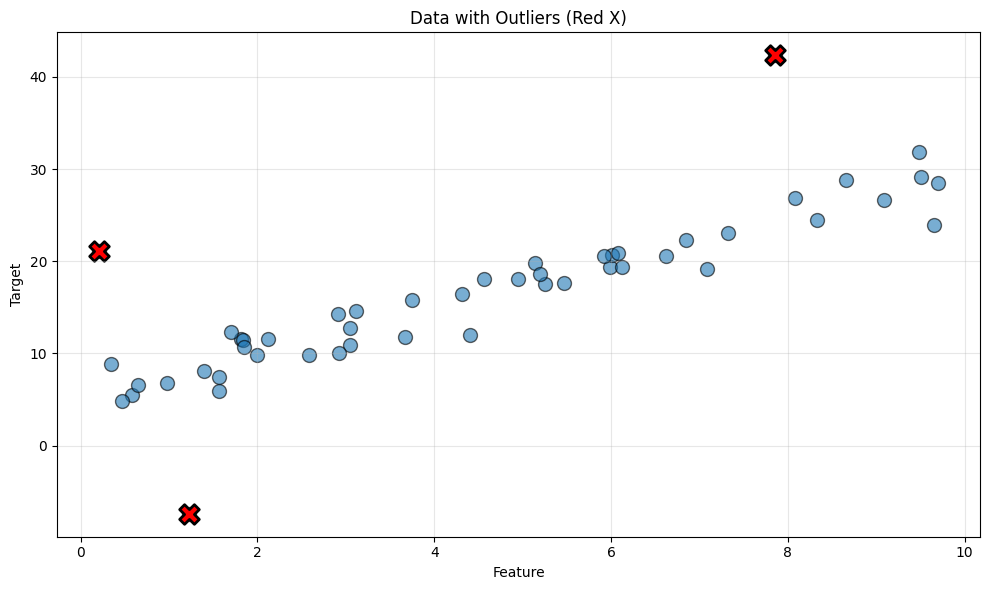


Notice: Red X = outliers that will mess up linear regression


In [2]:
# Generate data
X = np.random.rand(50, 1) * 10
y = 2.5 * X.flatten() + 5 + np.random.normal(0, 2, 50)

# Add some outliers
outlier_indices = [10, 25, 40]
for idx in outlier_indices:
    y[idx] += np.random.choice([-1, 1]) * 15

df = pd.DataFrame({'X': X.flatten(), 'Y': y})
print("Dataset with Outliers:")
print(df.head(15))

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, alpha=0.6, edgecolors='black')
# Highlight outliers
for idx in outlier_indices:
    plt.scatter(X[idx], y[idx], s=200, color='red', marker='X', edgecolors='black', linewidths=2)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Data with Outliers (Red X)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNotice: Red X = outliers that will mess up linear regression")

---
## 2. SVR: Epsilon Tube Concept

In [3]:
print("SVR Epsilon Tube:")
print("="*50)
print("\nIdea: Accept small errors within epsilon tube")
print("\nLinear Regression:")
print("  Cost = Σ(actual - predicted)²")
print("  Minimizes ALL errors")
print("  Outliers have huge influence")

print("\nSVR with epsilon=1:")
print("  If |error| < 1: No penalty")
print("  If |error| >= 1: Linear penalty")
print("  Less influenced by outliers!")

print("\nSVR with epsilon=2:")
print("  Wider tube → Even more tolerant")
print("  Less precise but more robust")

SVR Epsilon Tube:

Idea: Accept small errors within epsilon tube

Linear Regression:
  Cost = Σ(actual - predicted)²
  Minimizes ALL errors
  Outliers have huge influence

SVR with epsilon=1:
  If |error| < 1: No penalty
  If |error| >= 1: Linear penalty
  Less influenced by outliers!

SVR with epsilon=2:
  Wider tube → Even more tolerant
  Less precise but more robust


---
## 3. Train Different Models

In [4]:
# Scale features (important for SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linear Regression
model_linear = LinearRegression()
model_linear.fit(X_scaled, y)
y_pred_linear = model_linear.predict(X_scaled)

# SVR with linear kernel, epsilon=2
model_svr_eps2 = SVR(kernel='linear', epsilon=2, C=100)
model_svr_eps2.fit(X_scaled, y)
y_pred_svr_eps2 = model_svr_eps2.predict(X_scaled)

# SVR with linear kernel, epsilon=1
model_svr_eps1 = SVR(kernel='linear', epsilon=1, C=100)
model_svr_eps1.fit(X_scaled, y)
y_pred_svr_eps1 = model_svr_eps1.predict(X_scaled)

# SVR RBF kernel
model_svr_rbf = SVR(kernel='rbf', epsilon=1, C=100, gamma='scale')
model_svr_rbf.fit(X_scaled, y)
y_pred_svr_rbf = model_svr_rbf.predict(X_scaled)

print("Models trained!")

Models trained!


---
## 4. Compare Predictions

In [5]:
# Calculate metrics
metrics = {}
for name, y_pred in [('Linear', y_pred_linear), 
                      ('SVR-Linear-ε2', y_pred_svr_eps2),
                      ('SVR-Linear-ε1', y_pred_svr_eps1),
                      ('SVR-RBF', y_pred_svr_rbf)]:
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    metrics[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

results_df = pd.DataFrame(metrics).T
print("Model Comparison:")
print(results_df.round(4))

print("\n✅ SVR more robust to outliers!")
print("   (Slightly higher error on clean data is OK)")

Model Comparison:
                 RMSE     MAE      R²
Linear         4.3574  2.3654  0.7358
SVR-Linear-ε2  4.3694  2.3570  0.7343
SVR-Linear-ε1  4.3686  2.3565  0.7344
SVR-RBF        4.1435  2.3024  0.7611

✅ SVR more robust to outliers!
   (Slightly higher error on clean data is OK)


---
## 5. Visualize Models

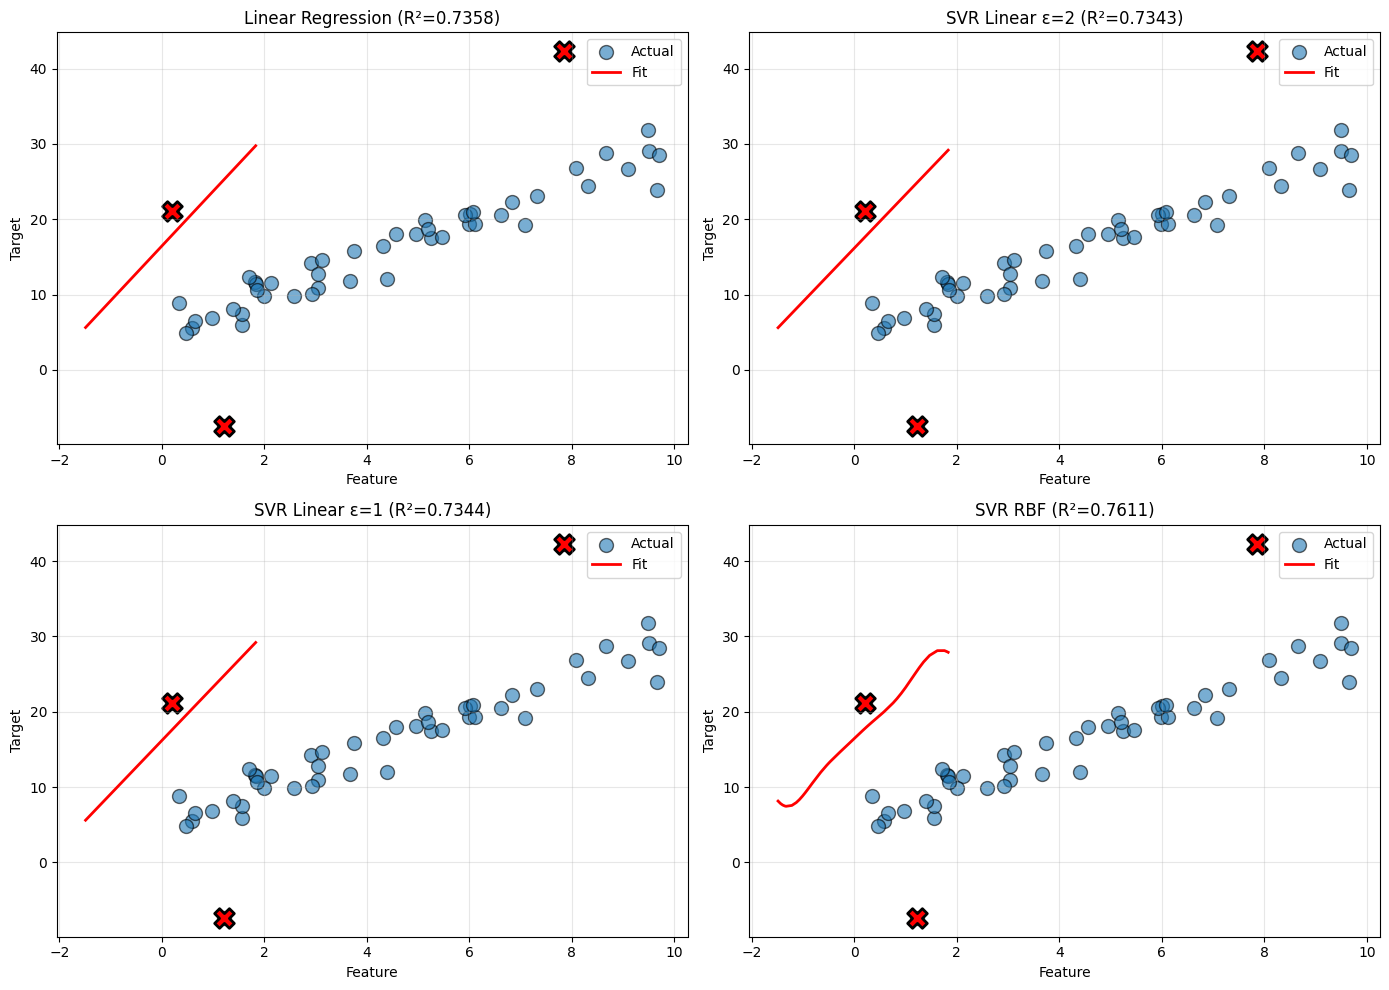

Notice: SVR lines don't pass through all outliers
        Linear reg is pulled toward outliers


In [6]:
# Sort for plotting
sort_idx = np.argsort(X_scaled.flatten())
X_sorted = X_scaled[sort_idx]
y_sorted = y[sort_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_to_plot = [
    ('Linear Regression', model_linear, axes[0, 0]),
    ('SVR Linear ε=2', model_svr_eps2, axes[0, 1]),
    ('SVR Linear ε=1', model_svr_eps1, axes[1, 0]),
    ('SVR RBF', model_svr_rbf, axes[1, 1])
]

for name, model, ax in models_to_plot:
    y_pred_sorted = model.predict(X_sorted)
    
    ax.scatter(X, y, s=100, alpha=0.6, label='Actual', edgecolors='black')
    # Highlight outliers
    for idx in outlier_indices:
        ax.scatter(X[idx], y[idx], s=200, color='red', marker='X', edgecolors='black', linewidths=2)
    ax.plot(X_sorted, y_pred_sorted, 'r-', linewidth=2, label='Fit')
    
    r2 = r2_score(y, model.predict(X_scaled))
    ax.set_title(f'{name} (R²={r2:.4f})')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Target')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: SVR lines don't pass through all outliers")
print("        Linear reg is pulled toward outliers")

---
## 6. SVR Hyperparameters

In [7]:
print("SVR Hyperparameters:")
print("="*50)

print("\nC (Regularization):")
print("  - High C: Fit training data closely (risk overfitting)")
print("  - Low C: Simpler model, more generalization")
print("  - Default: 1.0, Try: 0.1, 1, 10, 100")

print("\nEpsilon (ε):")
print("  - Width of tube where no penalty")
print("  - High ε: Robust but less precise")
print("  - Low ε: Precise but sensitive to noise")
print("  - Default: 0.1, Try: 0.01, 0.1, 1, 5")

print("\nKernel:")
print("  - 'linear': For linear relationships")
print("  - 'rbf': For non-linear (Gaussian)")
print("  - 'poly': Polynomial (rarely used)")

print("\nGamma (for RBF):")
print("  - High gamma: Complex fit, risk overfitting")
print("  - Low gamma: Simpler fit")
print("  - 'scale': 1/(n_features × X.var())")

SVR Hyperparameters:

C (Regularization):
  - High C: Fit training data closely (risk overfitting)
  - Low C: Simpler model, more generalization
  - Default: 1.0, Try: 0.1, 1, 10, 100

Epsilon (ε):
  - Width of tube where no penalty
  - High ε: Robust but less precise
  - Low ε: Precise but sensitive to noise
  - Default: 0.1, Try: 0.01, 0.1, 1, 5

Kernel:
  - 'linear': For linear relationships
  - 'rbf': For non-linear (Gaussian)
  - 'poly': Polynomial (rarely used)

Gamma (for RBF):
  - High gamma: Complex fit, risk overfitting
  - Low gamma: Simpler fit
  - 'scale': 1/(n_features × X.var())


---
## 7. Hyperparameter Tuning

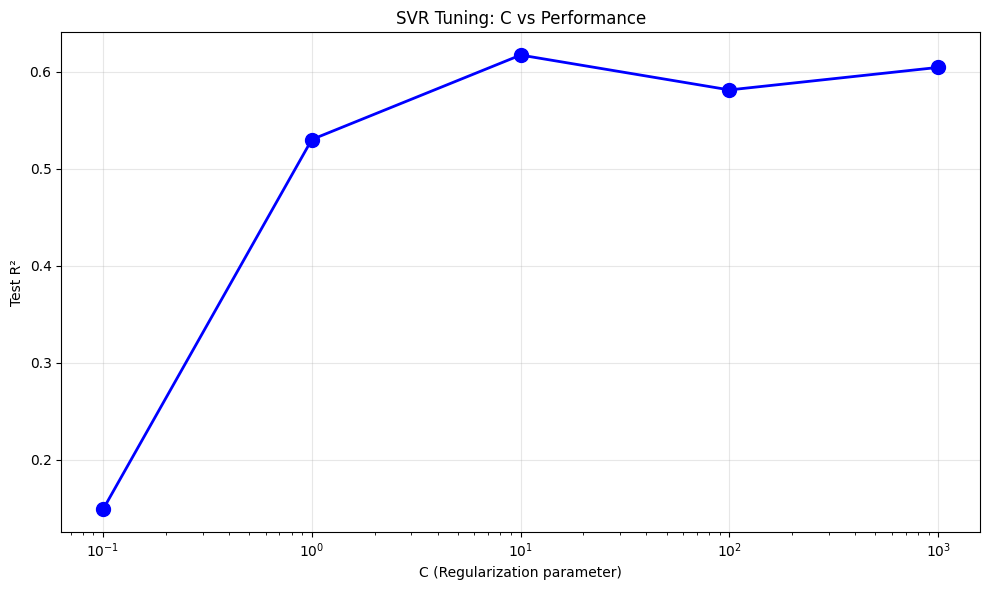


Best C: 10
Note: Usually C=1-100 works well


In [8]:
# Test different C values
C_values = [0.1, 1, 10, 100, 1000]
test_scores = []

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for C in C_values:
    model = SVR(kernel='rbf', epsilon=1, C=C, gamma='scale')
    model.fit(X_train, y_train)
    test_score = model.score(X_test, y_test)
    test_scores.append(test_score)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(C_values, test_scores, 'bo-', linewidth=2, markersize=10)
plt.xscale('log')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Test R²')
plt.title('SVR Tuning: C vs Performance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C = C_values[np.argmax(test_scores)]
print(f"\nBest C: {best_C}")
print("Note: Usually C=1-100 works well")

---
## Key Takeaways

1. **SVR**: Regression using SVM concept
2. **Epsilon tube**: Tolerance for small errors
3. **Robust to outliers**: Doesn't overfit to noise
4. **Scale data**: Important for SVM algorithms
5. **C parameter**: Balance fit vs generalization
6. **RBF kernel**: Good for non-linear patterns
7. **Trade-off**: Slightly higher training error, better generalization

Great choice when linear regression fails and data has outliers!

---
## Your Turn

1. Load dataset with outliers
2. Train Linear Regression vs SVR
3. Try different kernels (linear, rbf, poly)
4. Tune C and epsilon
5. Evaluate test performance

In [9]:
# Your code here